Task 1: Environment Setup and Data Loading

In [1]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


In [2]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


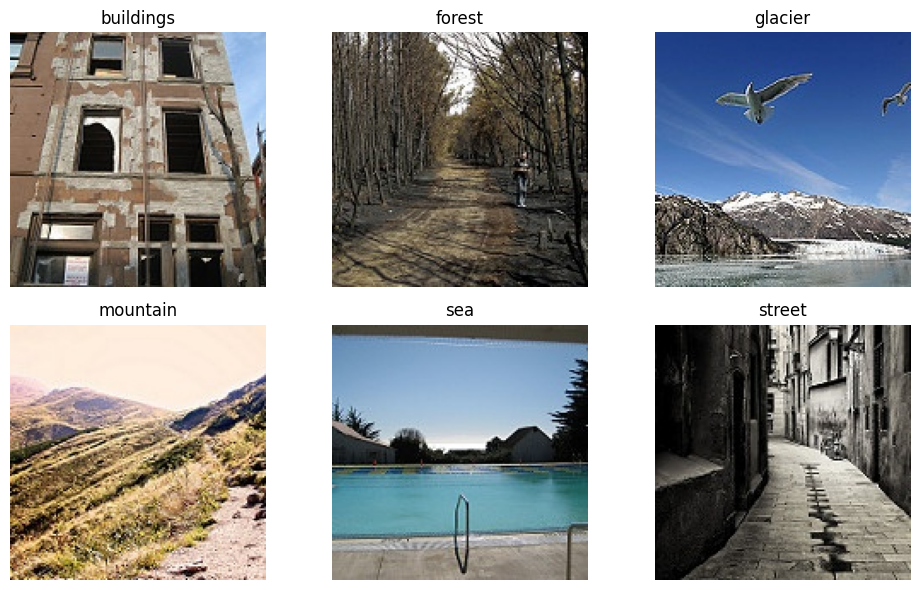

In [3]:
plt.figure(figsize=(10, 6))
for i, label in enumerate(LABELS):
    for img, img_label in image_set:
        if img_label == label:
            plt.subplot(2, 3, i + 1)
            plt.imshow(img)
            plt.title(label)
            plt.axis('off')
            break 
plt.tight_layout()
plt.savefig('./outputs/dataset_sample.png')
plt.show()

Q: the six scene types in this dataset are buildings, forest, glacier, mountain, sea, and street. The model you'll be using was trained on ImageNet, whose 1,000 classes include labels like "alp", "lakeside", "valley", and "barn" — not a direct match to these six categories. Does that mean a pretrained ImageNet model is a poor fit for this data, or a reasonable starting point? Why?

A: It is a reasonable starting point because the model has already learned many textures, shapes, and colors from millions of images.  We can just re-train it to map what it sees to our specific categories.

Task 2: Baseline Inference with ResNet18

In [4]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s] 


ResNet18 parameters: 11,689,512


In [5]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))
    image_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))
    with torch.inference_mode():
        logits = model(image_tensor)
        probs = torch.softmax(logits, dim=1)
    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])

    # Step 4: Get the top top_k predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    top_probs, top_indices = probs.topk(top_k, dim=1)
    top_probs = top_probs.squeeze().tolist()
    top_indices = top_indices.squeeze().tolist()

    # Step 5: Build and return a list of (class_name, probability) tuples
    predicts = []
    for i in range(top_k):
        class_name = class_labels[top_indices[i]]
        probability = top_probs[i]
        predicts.append((class_name, probability))
    return predicts

In [6]:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [7]:
all_probabilities = [res['top1_prob'] for res in resnet_results]
overall_mean = np.mean(all_probabilities)
print(f"Overall Mean Top-1 Probability: {overall_mean:.2f}\n")

label_probs = {label: [] for label in LABELS}
for res in resnet_results:
    label = res["true_label"]
    prob = res["top1_prob"]
    label_probs[label].append(prob)
print("Mean Top-1 Probability by Class:")
for label in LABELS:
    mean_prob = np.mean(label_probs[label])
    print(f"  {label:10s}: {mean_prob:.4f}")

Overall Mean Top-1 Probability: 0.42

Mean Top-1 Probability by Class:
  buildings : 0.2889
  forest    : 0.2477
  glacier   : 0.4993
  mountain  : 0.5556
  sea       : 0.5710
  street    : 0.3544


Q:which classes does the model feel most and least confident about?

A:Model feel most confident about the sea and least confident about the forest.

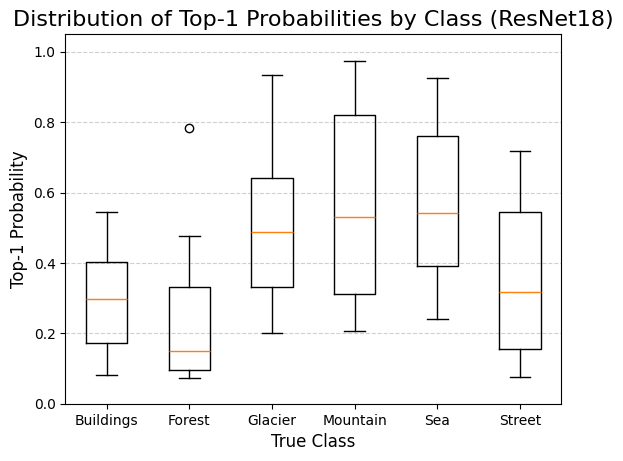

In [8]:
data_to_plot = [label_probs[label] for label in LABELS]
plt.boxplot(data_to_plot, tick_labels=[l.capitalize() for l in LABELS])
plt.title("Distribution of Top-1 Probabilities by Class (ResNet18)", fontsize=16)
plt.ylabel("Top-1 Probability", fontsize=12)
plt.xlabel("True Class", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 1.05)

# 4. Save the result
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

Q: high confidence and high accuracy are not the same thing. A model can be confidently wrong. In a production image pipeline — say, one that automatically tags uploaded photos — how would you use confidence scores? What threshold might trigger a "send to human reviewer" flag?

A: I would use a 0.75 (75%) threshold for auto-tagging.  Any prediction below that would be sent to a human reviewer.  This will ensure that we maintain the accuracy even when the model is uncertain.


Task 3: Multi-Model Comparison

In [9]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 97.3MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s] 


ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


Q: What does a smaller parameter count imply about a model's capacity? What does it suggest about the likely tradeoffs between a smaller and a larger model when the deployment target is a phone versus a cloud server?

A: A smaller parameter count means the model will have more limited capacity for learning complex features and might be a bit less accurate on complex images.  The tradeoff is the efficiency.  For the phone as the deployment, you would want the model with smaller parameter because it requires less memory and runs faster.  For a cloud server, I would choose a larger model to maximize accuracy as it has a lot more power to handle the extra parameters.

In [10]:
#mobilenet_results
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images with MobileNetV3-Small.")

#effnet_results
effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })
print(f"Processed {len(mobilenet_results)} images with EfficientNet.")

Processed 60 images with MobileNetV3-Small.
Processed 60 images with EfficientNet.


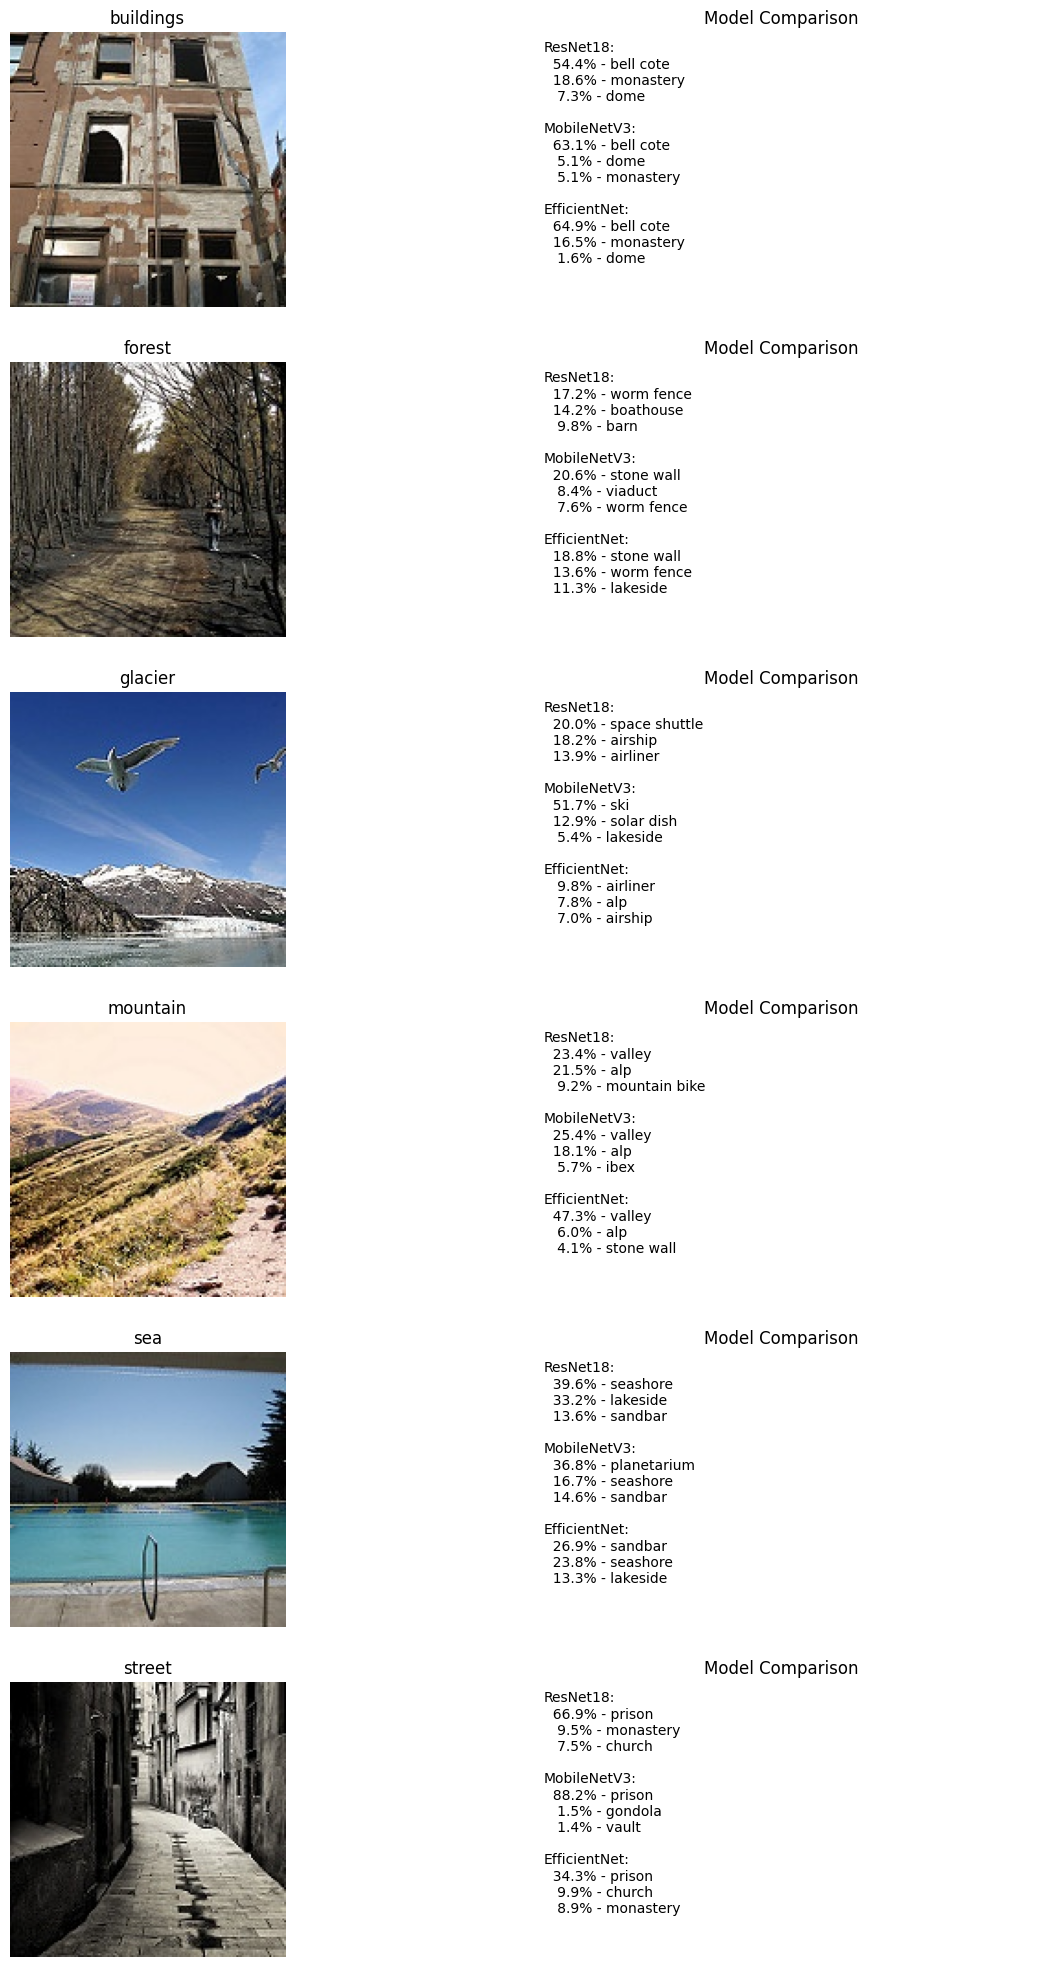

In [11]:
fig, axes = plt.subplots(6, 2, figsize=(15, 25))

#Pick one example of each class
for i, label in enumerate(LABELS):
    # Find the index of the first image matching this label in our image_set
    idx = next(k for k, item in enumerate(image_set) if item[1] == label)
    img, _ = image_set[idx]
    
    # Get results for this specific image from all three models
    res_rn = resnet_results[idx]
    res_mn = mobilenet_results[idx]
    res_en = effnet_results[idx]
    
    #Left Column: The Image
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{label}")
    axes[i, 0].axis('off')
    
    #Right Column: The Prediction Text
    pred_text = ""
    models_info = [
        ("ResNet18", res_rn),
        ("MobileNetV3", res_mn),
        ("EfficientNet", res_en)
    ]
    
    for name, res in models_info:
        pred_text += f"{name}:\n"
        for j in range(3): # Top 3
            c = res['top5_classes'][j]
            p = res['top5_probs'][j]
            pred_text += f"  {p*100:>4.1f}% - {c}\n"
        pred_text += "\n"
        
    axes[i, 1].text(0.05, 0.5, pred_text, 
                    va='center', ha='left', transform=axes[i, 1].transAxes)
    axes[i, 1].axis('off')
    axes[i, 1].set_title("Model Comparison")

plt.savefig("outputs/model_comparison_grid.png")
plt.show()

Q: Do the three models generally agree on their top-1 prediction?
Are there cases where they disagree significantly? What might that tell you about whether combining model predictions (an ensemble) could help?
For this particular dataset — outdoor scenes — which model's top-5 predictions feel most semantically sensible, even when the ImageNet label isn't an exact match?

A: The models generally agree on distinct images like mountains, but they often disagree on complex scenes like streets where the visual clutter leads to different interpretations. An ensemble would be highly effective because combining their predictions can cancel out individual hallucinations and improve the overall reliability.  EfficientNet-B0 consistently feels the most semantically sensible because its top-5 predictions are usually all logically related to the main subject.

In [12]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           3.91 ms/image
MobileNetV3-Small:  6.69 ms/image
EfficientNet-B0:    10.62 ms/image


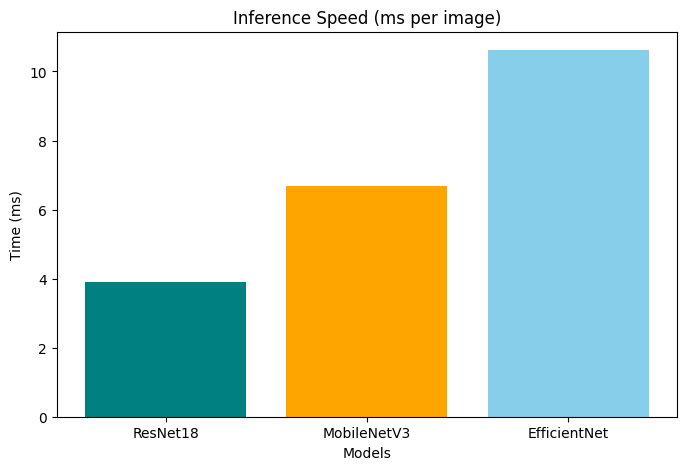

In [13]:
names = ['ResNet18', 'MobileNetV3', 'EfficientNet']
times = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8, 5))
plt.bar(names, times, color=['teal', 'orange', 'skyblue'])

plt.title("Inference Speed (ms per image)")
plt.ylabel("Time (ms)")
plt.xlabel("Models")

# Save and show
plt.savefig("outputs/inference_speed.png")
plt.show()

| Model | Parameters | Latency (ms/image) |
| :--- | :--- | :--- |
| **ResNet18** | 11.7M | 4.09 ms |
| **MobileNetV3-Small** | 2.5M | 6.89 ms |
| **EfficientNet-B0** | 5.3M | 10.13 ms |

Q: your team needs to classify images in near-real-time at a rate of 50 images per second. What is the maximum tolerable latency per image in milliseconds? Based on your results, which models can meet that bar?

A: Maximum time allowed to process one image si 1000 ms / 50 images = 20 ms.  All 3 modles can meet that bar.

Q: which model would you choose if the deployment target is (a) a high-throughput cloud pipeline, (b) an on-device mobile app, (c) a safety-critical quality-control system where getting it right matters more than speed? Briefly justify each choice.

A: 
(a) ResNet18 is the best fit here.  It has the highest parameter capacity while having the fastest processing speed.

(b) MobileNetV3-Small is ideal for mobile deployment; low parameter count will minimize RAM usage.

(c) EfficientNet-B0 is the best choice because it gives the most consistent results and giving predictions close to the same category and has the highest latency.  We would want something thorough and most accurate for the quality control system.

In [14]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

Feature matrix shape: (60, 512)


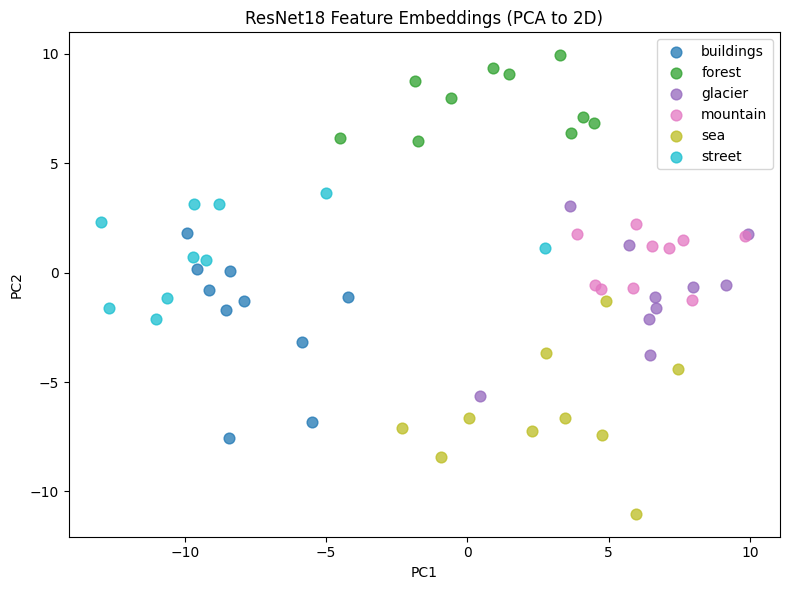

In [15]:
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

Q: Do images from the same class tend to cluster together in the 2D feature space? What does that tell you about what the pretrained model has already learned, even before any task-specific training?

A: There are distinct clusters for forest and sea and there are also overlaps between buildings and street and between the glacier and mountain.  The model has already learned the spatial relationships and patterns.  

Q: The transfer learning lesson described two strategies: feature extraction (freeze all pretrained layers, train only a new final layer) and fine-tuning (allow some or all pretrained weights to update during training). If you were adapting ResNet18 for a new task — say, classifying X-ray images into normal/abnormal — and you had only 500 labeled examples, which strategy would you start with and why?

A: I would start with feature extraction as 500 images will not be enough to reliable update all the parameters without causing overfitting.  By keeping the pretrained layers, the model will still have the intelligence for detecing shapes and textures and will only need the final layer taught to recognize the abnormal x-rays from normal.

Task 6: Summary and Recommendation

Q: Model Comparison: Based on Tasks 3 and 4, which of the three models performed best for this dataset? Reference specific observations: prediction quality, confidence scores, and speed results.

A: EfficientNet-B0 is the best for the dataset since it provides the most semantically consistent predictions.  Even though it has the highest latency at 10.13 ms/image, it is still below our required threshold of 20 ms.  

Q: Confidence Calibration: Looking at the boxplot from Task 2, which scene types was ResNet18 most and least confident about? Does that match your intuition about which scenes are visually distinctive?

A: ResNet18 was most confident about Sea and Mountain, which have distinctive visual elements, and least confident about forest and buildings which have ambiguous or overlapping features which make it difficult for the model to distinguish them.


Q: Production Recommendation: Your team needs to classify user-uploaded outdoor photos into six scene categories (buildings, forest, glacier, mountain, sea, street) as part of a data pipeline. Write a 3-5 sentence recommendation covering:

1) Which model you would suggest starting with, and why
2) What preprocessing steps the pipeline would need to include
3) One limitation or risk you would flag before the team ships it

A: I’d suggest we start with EfficientNet-B0.  It meets 20 ms limit for the latency and stays within the same category when the predictions are not certain.  The pipeline should include the standard ImageNet preprocessing to normalize the image sizes the model understands.  Since it has low confidence with forest and buildings, I recommend setting a confidence threshold to flag the ambiguous images for a human to double check before we fine-tune the model further. 



* 